SystemExit: 0

C:\Users\nkx00\anaconda3\Lib\site-packages\IPython\core\interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


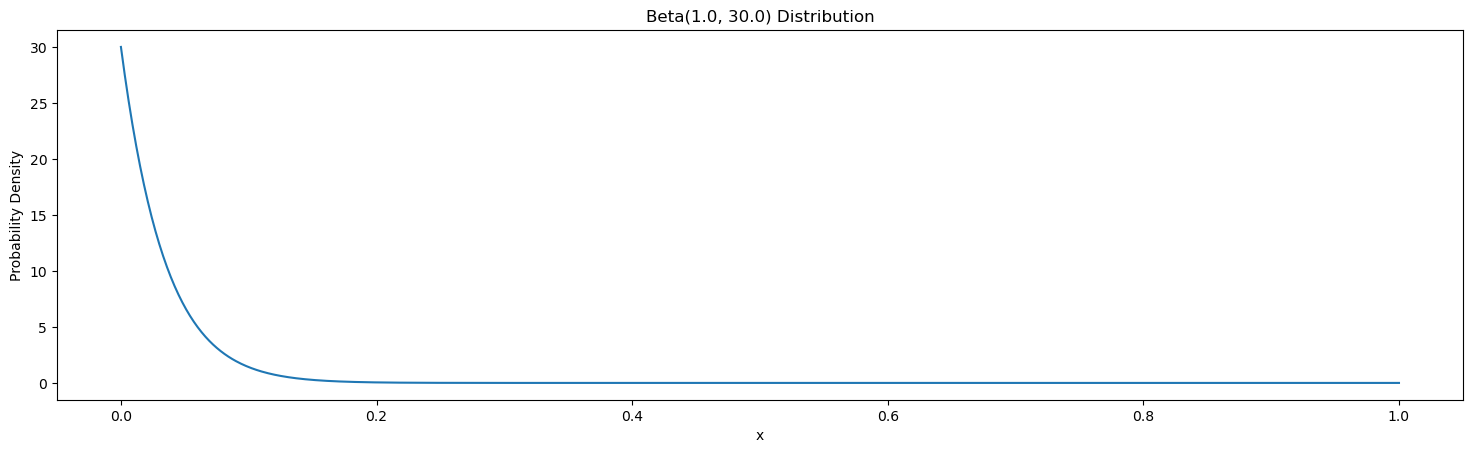

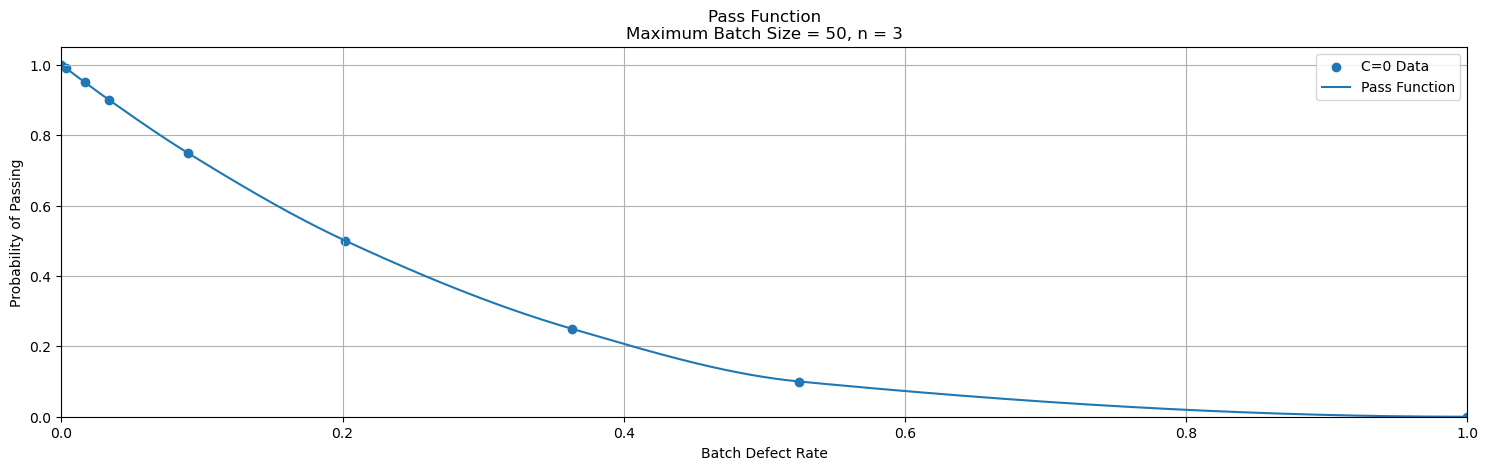

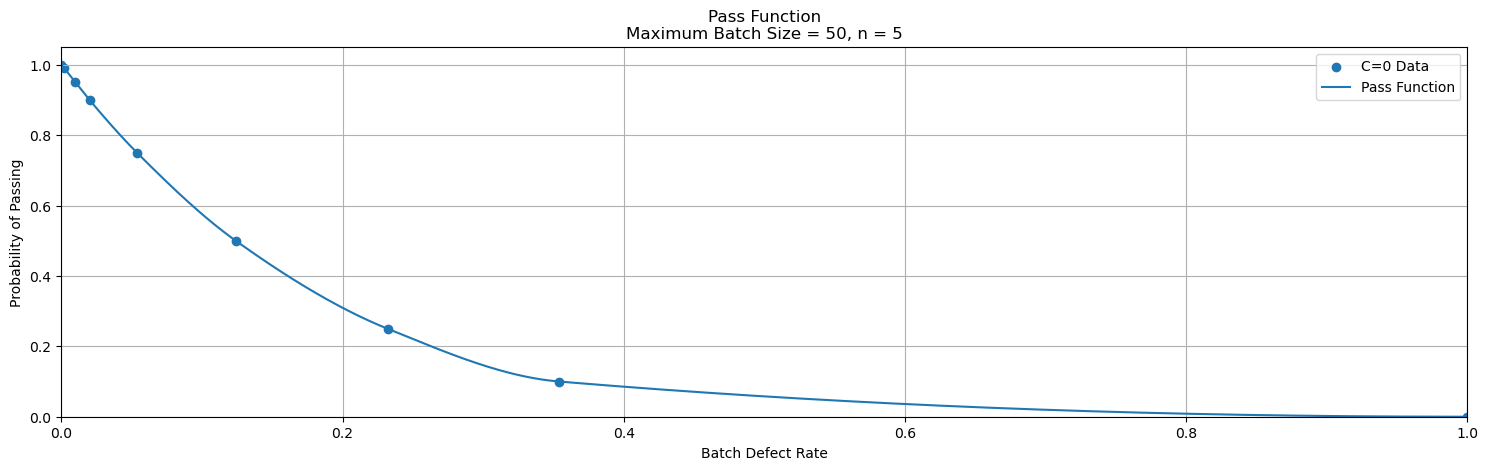

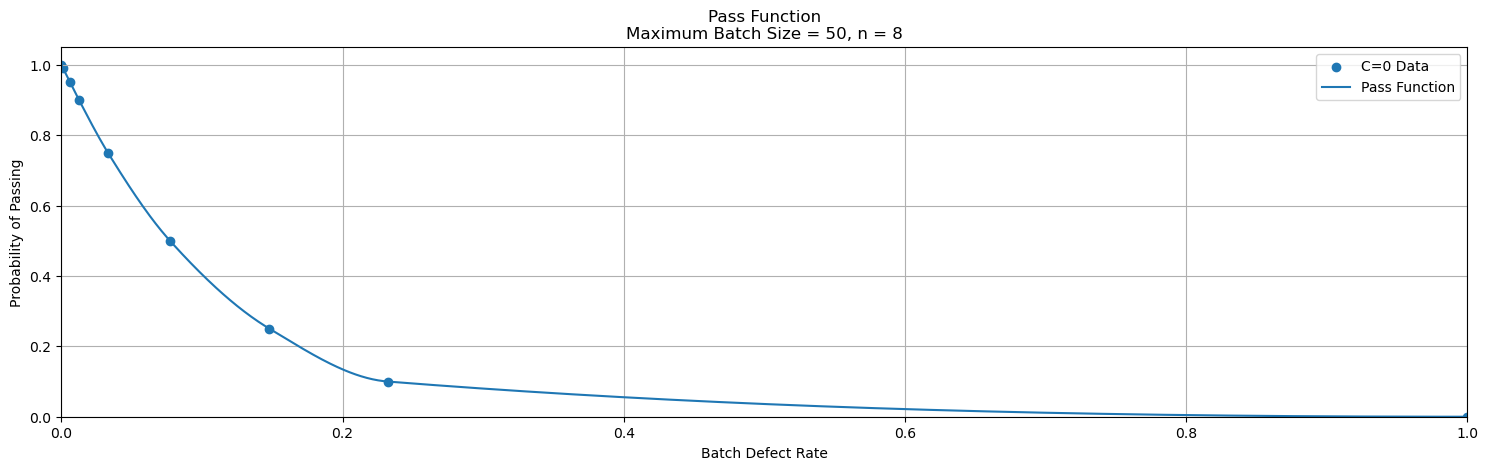

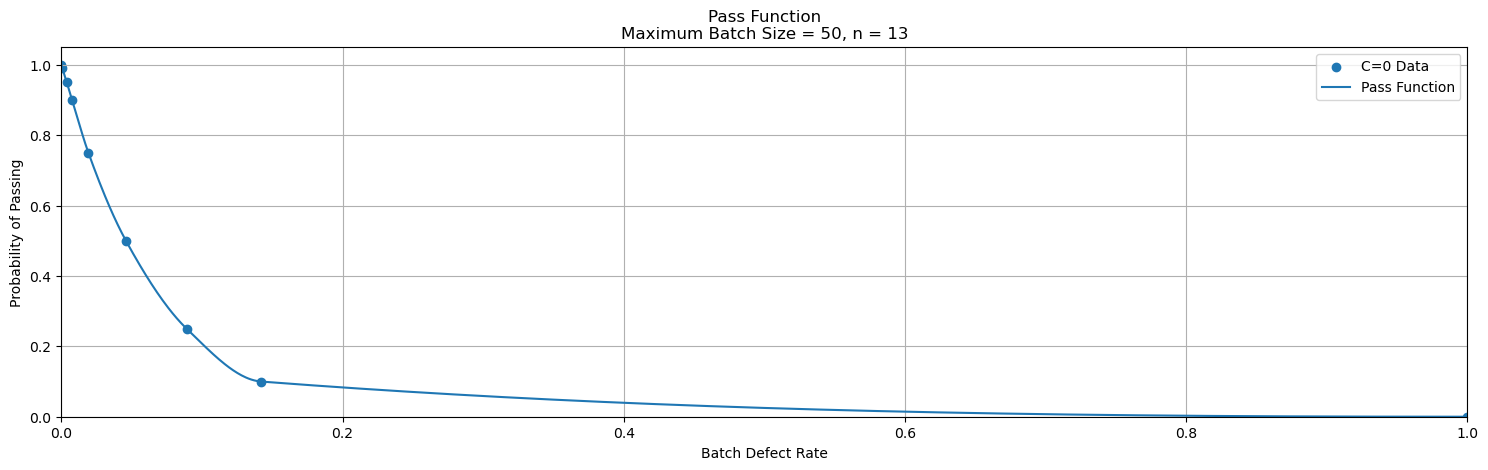

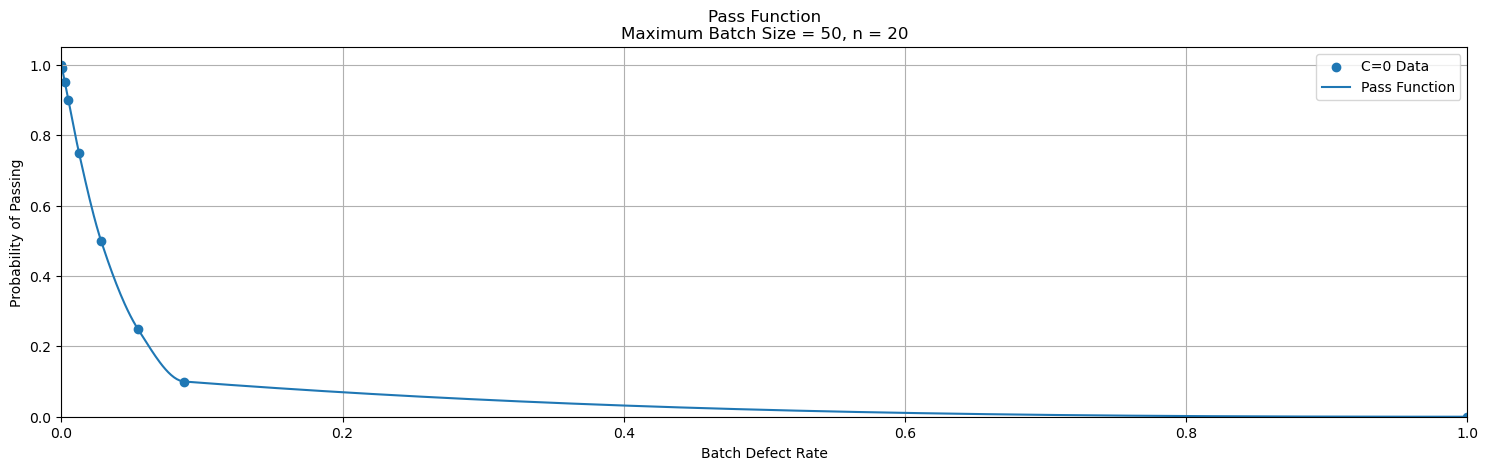

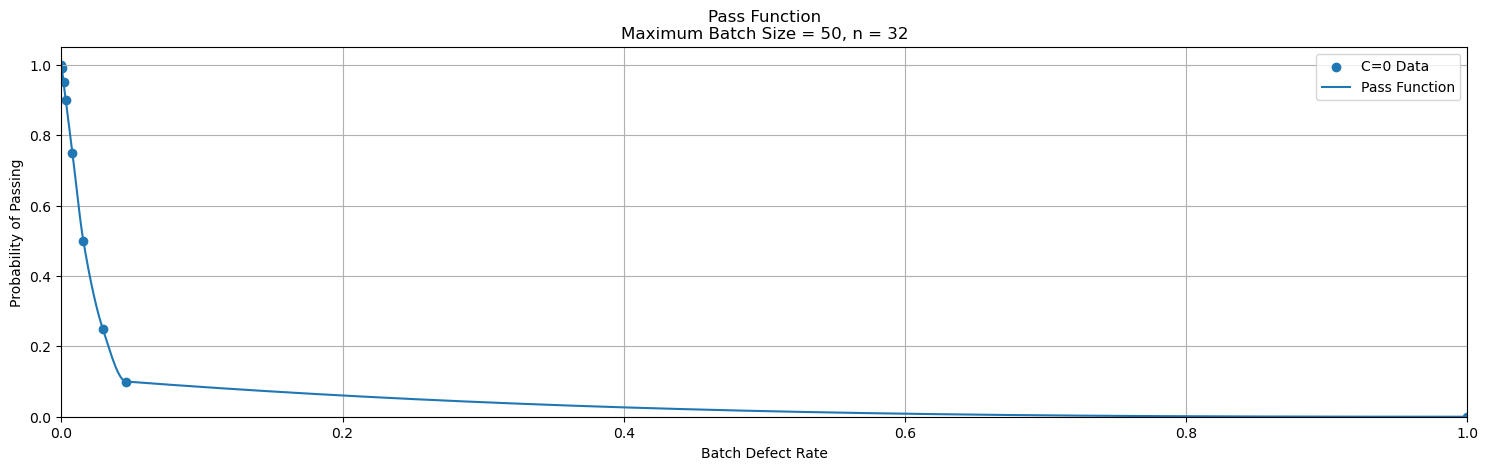

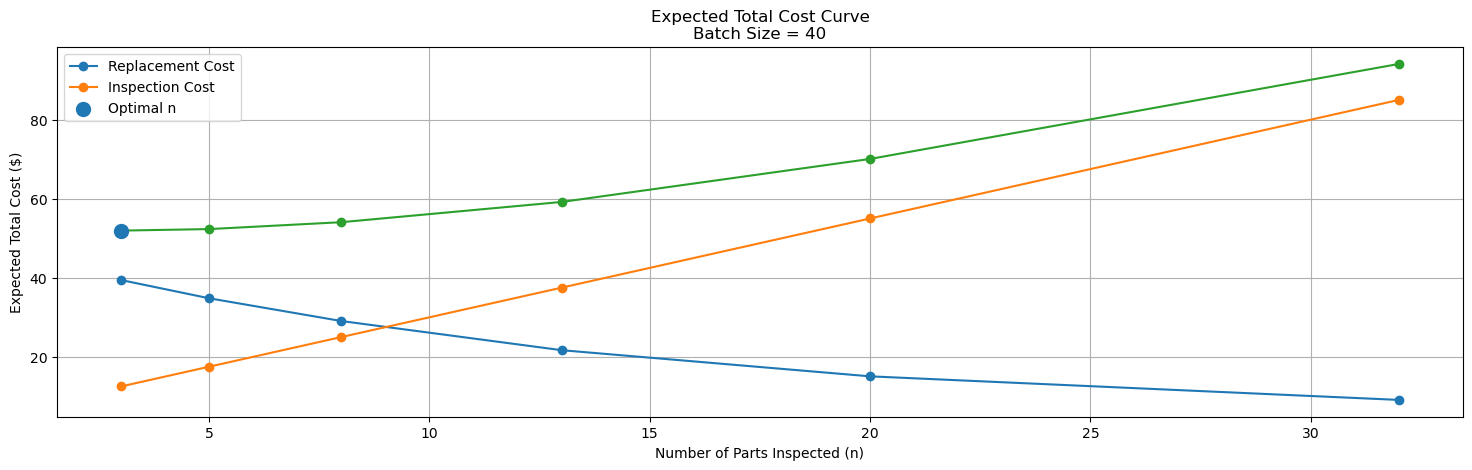

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import beta
from scipy.integrate import quad
from scipy.interpolate import PchipInterpolator
import matplotlib.pyplot as plt

import customtkinter as ctk
import builtins
import sys
import io
import os



input_values = []

input_window = ctk.CTk()
input_window.title("Inspection Sampling Program")
input_window.geometry("400x650")
input_window.resizable(False, False)


def close_input_window():
    input_window.destroy()
    sys.exit(0)


input_window.protocol("WM_DELETE_WINDOW", close_input_window)
input_frame = ctk.CTkFrame(input_window, corner_radius=10)

input_frame.pack(fill="both", expand=True, padx=20, pady=20)


ctk.CTkLabel(input_frame, text="Inspection Sampling Program", font=("Arial", 20, "bold")).pack(pady=(20, 30))


def create_input_box(label):

    ctk.CTkLabel(input_frame, text=label, anchor="w").pack(fill="x", padx=25)
    entry = ctk.CTkEntry(input_frame, width=300)
    entry.pack(padx=25, pady=(5, 12))
    return entry


part_cost_entry = create_input_box("Part Cost:")
inspection_cost_entry = create_input_box("Inspection Cost:")
initial_cost_entry = create_input_box("Initial Inspection Cost:")
batch_size_entry = create_input_box("Batch Size:")
alpha_entry = create_input_box("Alpha:")
beta_entry = create_input_box("Beta:")



def submit_inputs():
    input_values.clear()
    input_values.extend(
        [
            part_cost_entry.get(),
            inspection_cost_entry.get(),
            initial_cost_entry.get(),
            batch_size_entry.get(),
            alpha_entry.get(),
            beta_entry.get()
        ]
    )

    input_window.destroy()


ctk.CTkButton(input_frame, text="Run Calculation", width=300, height=40, command=submit_inputs).pack(pady=20)
input_index = 0


def gui_input(prompt=""):

    global input_index

    if len(input_values) == 0:

        input_window.mainloop()

    if len(input_values) == 0:

        sys.exit(0)

    value = input_values[input_index]

    input_index += 1

    return value


builtins.input = gui_input
output_capture = io.StringIO()
original_stdout = sys.stdout
sys.stdout = output_capture


def store_plot(*args, **kwargs):
    pass


plt.show = store_plot


### MATH STARTS HERE

### USER INPUTS
part_cost = float(input("Enter Part Cost: "))
inspection_cost = float(input("Enter Inspection Cost: "))    
init_Inspection_cost = float(input("Enter Initial Inspection Cost: "))
batch_size = int(input("Enter Batch Size: "))
alpha_param = float(input("Enter Alpha: "))
beta_param = float(input("Enter Beta: "))

### BETA DISTRIBUTION CREATION AND GRAPH
beta_distribution = beta(a=alpha_param, b=beta_param)

def beta_pdf(x):
    return beta_distribution.pdf(x)

x_values = np.linspace(0, 1, 1000)
beta_values = beta_pdf(x_values)

plt.plot(x_values, beta_values)
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title(f'Beta({alpha_param}, {beta_param}) Distribution')
plt.show()


### LOAD C=0 DATA SET
c0_data = pd.read_csv("c0_data.csv")
c0_data.columns = ["max_batch_size", "n", "pass_probability", "defect_rate"]


### FUNCTION TO PICK OUT A SUBSET OF THE DATA THAT CORRESPONDS TO THE USER SPECIFIED BATCH SIZE 
def get_c0_batch_size(c0_data, batch_size):
    available_sizes = np.sort(c0_data["max_batch_size"].unique())

    valid_sizes = available_sizes[available_sizes >= batch_size]

    if len(valid_sizes) == 0:
        raise ValueError("The entered batch size is larger than the largest C=0 batch-size category.")

    return valid_sizes[0]


max_batch_size = get_c0_batch_size(c0_data, batch_size)

print(f"\nActual batch size: {batch_size}")
print(f"C=0 maximum batch-size category: "f"{max_batch_size}")

batch_data = c0_data[c0_data["max_batch_size"] == max_batch_size]
n_values = sorted(batch_data["n"].unique())  ### SELECTS THE POSSIBLE "n" VALUES FOR THE GIVEN BATCH SIZE

print("\nAvailable inspection quantities:")
print(n_values)


### FUNCTION TO CREATE A CONTINUOUS FUNCTION FROM THE 7 C=0 DATA POINTS
def create_pass_function(c0_data, max_batch_size, n):

    subset = c0_data[(c0_data["max_batch_size"] == max_batch_size) & (c0_data["n"] == n)].copy()

    if subset.empty:
        raise ValueError(f"No C=0 data found for "f"maximum batch size {max_batch_size} "f"and n = {n}.")

    subset = subset.sort_values("defect_rate")

    x_data = subset["defect_rate"].to_numpy()
    pass_data = subset["pass_probability"].to_numpy()

    x_data = np.concatenate(([0.0], x_data, [1.0]))
    pass_data = np.concatenate(([1.0], pass_data, [0.0]))

    pass_function = PchipInterpolator(x_data, pass_data)


    
    return (pass_function, x_data, pass_data)


### FUNCTION TO CALCULATE THE REPLACEMENT COST INTEGRAL FOR A GIVEN VALUE OF "n"
def calculate_replacement_cost(beta_pdf, pass_function, batch_size, part_cost):

    def integrand(x):
        return (beta_pdf(x) * pass_function(x) * (x * batch_size) * part_cost)

    replacement_cost, integration_error = quad(integrand, 0, 1)
    
    return (replacement_cost, integration_error)



results = []


### FOR LOOP TO CALCULATE THE TOTAL COST FOR EVERY VALUE OF "n"
for n in n_values:

    (pass_function, x_data, pass_data) = create_pass_function(c0_data, max_batch_size, n)

    x_plot = np.linspace(0, 1, 1000)
    pass_plot = pass_function(x_plot)

    pass_plot = np.clip(pass_plot, 0, 1)
    
    plt.figure()
    plt.scatter(x_data, pass_data, label="C=0 Data")
    plt.plot(x_plot, pass_plot, label="Pass Function")
    plt.xlabel("Batch Defect Rate")
    plt.ylabel("Probability of Passing")
    plt.title(f"Pass Function\n" f"Maximum Batch Size = {max_batch_size}, "f"n = {n}")
    plt.xlim(0, 1)
    plt.ylim(0, 1.05)
    plt.legend()
    plt.grid(True)
    plt.show()


    (replacement_cost, integration_error) = calculate_replacement_cost(beta_pdf, pass_function, batch_size, part_cost)

    variable_inspection_cost = (n * inspection_cost)

    total_inspection_cost = (init_Inspection_cost + variable_inspection_cost)

    total_cost = (replacement_cost + total_inspection_cost)

### DICTIONARY TO STORE DATA FROM THE FOR LOOP
    results.append(
        {
            "n": n,
            "replacement_cost": replacement_cost,
            "inspection_cost": variable_inspection_cost,
            "initial_inspection_cost":
                init_Inspection_cost,
            "total_inspection_cost":
                total_inspection_cost,
            "total_cost": total_cost,
            "integration_error":
                integration_error
        }
    )

### CONVERTING DICTIONARY TO DATAFRAME
results_df = pd.DataFrame(results)


### TEXT DATA OUTPUTS 
print("\n")
print("=" * 65)
print("EXPECTED COST RESULTS")
print("=" * 65)

print(results_df.to_string(index=False))



optimal_index = (results_df["total_cost"].idxmin())
optimal_row = (results_df.loc[optimal_index])
optimal_n = int(optimal_row["n"])
optimal_total_cost = (optimal_row["total_cost"])
optimal_replacement_cost = (optimal_row["replacement_cost"])
optimal_inspection_cost = (optimal_row["total_inspection_cost"])



print("\n")
print("=" * 65)
print("OPTIMAL INSPECTION PLAN")
print("=" * 65)

print(f"Actual batch size: "f"{batch_size}")
print(f"C=0 maximum batch-size category: "f"{max_batch_size}")
print(f"Optimal number of inspections: "f"{optimal_n}")
print(f"Expected replacement cost: "f"${optimal_replacement_cost:,.2f}")
print(f"Total inspection cost: "f"${optimal_inspection_cost:,.2f}")
print(f"Minimum expected total cost: "f"${optimal_total_cost:,.2f}")

### FINAL COST CURVE GRAPH WITH TOTAL COST, REPLACEMENT COST, AND INSPECTION COST
plt.figure()

plt.plot(results_df["n"], results_df["replacement_cost"], marker="o", label="Replacement Cost")
plt.plot(results_df["n"], results_df["total_inspection_cost"], marker="o", label="Inspection Cost")
plt.plot(results_df["n"], results_df["total_cost"], marker="o")
plt.scatter(optimal_n,optimal_total_cost,s=100,zorder=5,label="Optimal n")
plt.xlabel("Number of Parts Inspected (n)")
plt.ylabel("Expected Total Cost ($)")
plt.title(f"Expected Total Cost Curve\n"f"Batch Size = {batch_size}")
plt.legend()
plt.grid(True)
plt.show()

### MATH ENDS HERE, CHAT GPT TKINTER SLOP CONTINUES BELOW



sys.stdout = original_stdout
output_text = output_capture.getvalue()
results_window = ctk.CTk()
results_window.title("Inspection Sampling Results")
results_window.geometry("1300x900")
results_window.minsize(900, 650)


def close_results_window():
    results_window.destroy()
    sys.exit(0)


results_window.protocol("WM_DELETE_WINDOW", close_results_window)

main_frame = ctk.CTkFrame(results_window, corner_radius=0)
main_frame.pack(fill="both", expand=True, padx=10, pady=10)

ctk.CTkLabel(main_frame, text="Inspection Sampling Results", font=("Arial", 24, "bold")).pack(pady=(10, 15))


results_section = ctk.CTkFrame(main_frame, corner_radius=10)
results_section.pack(fill="x", padx=10, pady=(0, 10))

ctk.CTkLabel(results_section, text="Calculation Results", font=("Arial", 18, "bold")).pack(anchor="w", padx=15, pady=(10, 5))

results_box = ctk.CTkTextbox(results_section, height=150, wrap="none", font=("Courier New", 12))
results_box.pack(fill="both", expand=True, padx=10, pady=(5, 10))


results_box.insert("1.0", output_text)
results_box.configure(state="disabled")


graph_section = ctk.CTkFrame(main_frame, corner_radius=10)
graph_section.pack(fill="both", expand=True, padx=10, pady=(0, 10))


ctk.CTkLabel(graph_section, text="Graphs", font=("Arial", 18, "bold")).pack( anchor="w", padx=15, pady=(10, 5))


graph_scroll_frame = ctk.CTkScrollableFrame(graph_section, orientation="vertical")
graph_scroll_frame.pack(fill="both", expand=True, padx=10, pady=(5, 10))


from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

for figure_number in plt.get_fignums():

    figure = plt.figure(figure_number)
    figure_canvas = FigureCanvasTkAgg(figure, master=graph_scroll_frame)
    figure_canvas.draw()
    figure_widget = figure_canvas.get_tk_widget()
    figure_widget.pack(fill="x", expand=False, pady=15)



button_frame = ctk.CTkFrame(main_frame, fg_color="transparent")
button_frame.pack(fill="x", pady=(0, 5))



def reset_program():

    results_window.destroy()
    os.execl(sys.executable, sys.executable, *sys.argv)

ctk.CTkButton(button_frame, text="Reset", width=150, height=35, command=reset_program).pack( side="left", padx=10)
ctk.CTkButton(button_frame, text="Close", width=150, height=35, command=close_results_window).pack( side="right", padx=10)


results_window.mainloop()